In [2]:
#Connect mysql to python

In [3]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

In [4]:
pip install mysql-connector-python

Note: you may need to restart the kernel to use updated packages.


In [5]:
import mysql.connector

In [6]:
conn=mysql.connector.connect(
host='localhost',
user='root',
password='root',
database='customer_behavior')

In [7]:
cursor=conn.cursor()                             #creates cursor object that lets you execute sql queries
cursor.execute('select * from customer_shopping_behavior')       #send sql queries to database
for row in cursor.fetchall():
    print(row)

(1, 55, 'Male', 'Blouse', 'Clothing', 53, 'Kentucky', 'L', 'Gray', 'Winter', 3.1, 'Yes', 'Express', 'Yes', 'Yes', 14, 'Venmo', 'Fortnightly')
(2, 19, 'Male', 'Sweater', 'Clothing', 64, 'Maine', 'L', 'Maroon', 'Winter', 3.1, 'Yes', 'Express', 'Yes', 'Yes', 2, 'Cash', 'Fortnightly')
(3, 50, 'Male', 'Jeans', 'Clothing', 73, 'Massachusetts', 'S', 'Maroon', 'Spring', 3.1, 'Yes', 'Free Shipping', 'Yes', 'Yes', 23, 'Credit Card', 'Weekly')
(4, 21, 'Male', 'Sandals', 'Footwear', 90, 'Rhode Island', 'M', 'Maroon', 'Spring', 3.5, 'Yes', 'Next Day Air', 'Yes', 'Yes', 49, 'PayPal', 'Weekly')
(5, 45, 'Male', 'Blouse', 'Clothing', 49, 'Oregon', 'M', 'Turquoise', 'Spring', 2.7, 'Yes', 'Free Shipping', 'Yes', 'Yes', 31, 'PayPal', 'Annually')
(6, 46, 'Male', 'Sneakers', 'Footwear', 20, 'Wyoming', 'M', 'White', 'Summer', 2.9, 'Yes', 'Standard', 'Yes', 'Yes', 14, 'Venmo', 'Weekly')
(7, 63, 'Male', 'Shirt', 'Clothing', 85, 'Montana', 'M', 'Gray', 'Fall', 3.2, 'Yes', 'Free Shipping', 'Yes', 'Yes', 49, 'Cas

Exploratory Data Analysis

Sql Analysis

In [8]:
df=pd.read_sql('Select * from customer_shopping_behavior',conn)
df

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3858,3896,40,Female,Hoodie,Clothing,28,Virginia,L,Turquoise,Summer,4.2,No,2-Day Shipping,No,No,32,Venmo,Weekly
3859,3897,52,Female,Backpack,Accessories,49,Iowa,L,White,Spring,4.5,No,Store Pickup,No,No,41,Bank Transfer,Bi-Weekly
3860,3898,46,Female,Belt,Accessories,33,New Jersey,L,Green,Spring,2.9,No,Standard,No,No,24,Venmo,Quarterly
3861,3899,44,Female,Shoes,Footwear,77,Minnesota,S,Brown,Summer,3.8,No,Express,No,No,24,Venmo,Weekly


In [9]:
pd.read_sql('desc customer_shopping_behavior',conn)

,Field,Type,Null,Key,Default,Extra
0,Customer ID,int,NO,PRI,None,
1,Age,int,YES,,None,
2,Gender,varchar(20),YES,,None,
3,Item Purchased,varchar(20),YES,,None,
4,Category,varchar(20),YES,,None,
5,Purchase Amount (USD),int,YES,,None,
6,Location,varchar(20),YES,,None,
7,Size,varchar(20),YES,,None,
8,Color,varchar(20),YES,,None,
9,Season,varchar(20),YES,,None,


In [10]:
cursor.execute("""
ALTER TABLE customer_shopping_behavior
modify Gender varchar(20),
modify `Item Purchased` varchar(20),	
modify Category varchar(20),
modify Location varchar(20),
modify Size varchar(20),
modify Color varchar(20),
modify Season varchar(20),
modify `Subscription Status` varchar(20),
modify `Shipping Type` varchar(20),
modify `Discount Applied` varchar(20),
modify `Promo Code Used` varchar(20),
modify `Payment Method` varchar(20),
modify `Frequency of Purchases` varchar(20)
""")
conn.commit()

In [11]:
cursor.execute("alter table customer_shopping_behavior change `ï»¿Customer ID` `Customer ID` int")


ProgrammingError: 1054 (42S22): Unknown column 'ï»¿Customer ID' in 'customer_shopping_behavior'

In [12]:
#`` - it treats it as one column name for column with space
cursor.execute("alter table customer_shopping_behavior modify `Customer ID` int primary key")
conn.commit()            #to save changes to database permanently

ProgrammingError: 1068 (42000): Multiple primary key defined

In [13]:
pd.read_sql('desc customer_shopping_behavior',conn)

,Field,Type,Null,Key,Default,Extra
0,Customer ID,int,NO,PRI,None,
1,Age,int,YES,,None,
2,Gender,varchar(20),YES,,None,
3,Item Purchased,varchar(20),YES,,None,
4,Category,varchar(20),YES,,None,
5,Purchase Amount (USD),int,YES,,None,
6,Location,varchar(20),YES,,None,
7,Size,varchar(20),YES,,None,
8,Color,varchar(20),YES,,None,
9,Season,varchar(20),YES,,None,


In [14]:
pd.read_sql('select * from customer_shopping_behavior',conn)

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3858,3896,40,Female,Hoodie,Clothing,28,Virginia,L,Turquoise,Summer,4.2,No,2-Day Shipping,No,No,32,Venmo,Weekly
3859,3897,52,Female,Backpack,Accessories,49,Iowa,L,White,Spring,4.5,No,Store Pickup,No,No,41,Bank Transfer,Bi-Weekly
3860,3898,46,Female,Belt,Accessories,33,New Jersey,L,Green,Spring,2.9,No,Standard,No,No,24,Venmo,Quarterly
3861,3899,44,Female,Shoes,Footwear,77,Minnesota,S,Brown,Summer,3.8,No,Express,No,No,24,Venmo,Weekly


In [15]:
pd.read_sql('select `Item Purchased`,Category from customer_shopping_behavior group by `Item Purchased`,Category',conn) 

,Item Purchased,Category
0,Blouse,Clothing
1,Sweater,Clothing
2,Jeans,Clothing
3,Sandals,Footwear
4,Sneakers,Footwear
5,Shirt,Clothing
6,Shorts,Clothing
7,Coat,Outerwear
8,Handbag,Accessories
9,Shoes,Footwear


In [16]:
pd.read_sql('select category,Round(avg(`Review Rating`),2) as AvgRating from customer_shopping_behavior group by category ',conn)

,category,AvgRating
0,Clothing,3.72
1,Footwear,3.79
2,Outerwear,3.75
3,Accessories,3.77


In [17]:
pd.read_sql('select * from customer_shopping_behavior where `Review Rating`=(select max(`Review Rating`) from customer_shopping_behavior)',conn)

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,28,56,Male,Shorts,Clothing,56,Kentucky,L,Cyan,Summer,5.0,Yes,Next Day Air,Yes,Yes,7,Bank Transfer,Every 3 Months
1,112,26,Male,Belt,Accessories,75,Massachusetts,L,Purple,Summer,5.0,Yes,Free Shipping,Yes,Yes,9,Credit Card,Annually
2,375,69,Male,Jewelry,Accessories,78,Ohio,S,Purple,Spring,5.0,Yes,Store Pickup,Yes,Yes,39,Bank Transfer,Monthly
3,469,34,Male,Backpack,Accessories,38,Georgia,S,Peach,Fall,5.0,Yes,Free Shipping,Yes,Yes,16,Cash,Quarterly
4,508,65,Male,Shorts,Clothing,20,Maine,M,Magenta,Spring,5.0,Yes,Store Pickup,Yes,Yes,33,Debit Card,Fortnightly
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63,3647,69,Female,Jewelry,Accessories,68,Nevada,M,Maroon,Spring,5.0,No,2-Day Shipping,No,No,39,Debit Card,Fortnightly
64,3649,31,Female,Skirt,Clothing,67,New York,M,White,Winter,5.0,No,Free Shipping,No,No,45,Cash,Bi-Weekly
65,3802,26,Female,Blouse,Clothing,84,Kentucky,M,Peach,Spring,5.0,No,Store Pickup,No,No,36,PayPal,Fortnightly
66,3821,34,Female,Belt,Accessories,65,New Hampshire,M,Purple,Winter,5.0,No,Standard,No,No,34,Debit Card,Quarterly


In [18]:
pd.read_sql('select * from customer_shopping_behavior where`Discount Applied`="No"',conn)

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1678,65,Male,Jeans,Clothing,35,Oregon,L,Silver,Summer,3.3,No,Next Day Air,No,No,41,Debit Card,Weekly
1,1679,41,Male,Pants,Clothing,71,Ohio,S,Magenta,Summer,4.8,No,2-Day Shipping,No,No,30,Venmo,Fortnightly
2,1680,60,Male,Dress,Clothing,52,Massachusetts,S,Black,Fall,4.5,No,Next Day Air,No,No,24,Debit Card,Bi-Weekly
3,1681,61,Male,Shoes,Footwear,37,Louisiana,M,Olive,Summer,3.4,No,Store Pickup,No,No,6,Credit Card,Annually
4,1682,24,Male,Sneakers,Footwear,95,Virginia,L,Green,Winter,3.7,No,2-Day Shipping,No,No,14,Credit Card,Bi-Weekly
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2218,3896,40,Female,Hoodie,Clothing,28,Virginia,L,Turquoise,Summer,4.2,No,2-Day Shipping,No,No,32,Venmo,Weekly
2219,3897,52,Female,Backpack,Accessories,49,Iowa,L,White,Spring,4.5,No,Store Pickup,No,No,41,Bank Transfer,Bi-Weekly
2220,3898,46,Female,Belt,Accessories,33,New Jersey,L,Green,Spring,2.9,No,Standard,No,No,24,Venmo,Quarterly
2221,3899,44,Female,Shoes,Footwear,77,Minnesota,S,Brown,Summer,3.8,No,Express,No,No,24,Venmo,Weekly


In [19]:
pd.read_sql('select * from customer_shopping_behavior where `Shipping Type`="Free Shipping" and `Discount Applied`="Yes"',conn)

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
1,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually
2,7,63,Male,Shirt,Clothing,85,Montana,M,Gray,Fall,3.2,Yes,Free Shipping,Yes,Yes,49,Cash,Quarterly
3,8,27,Male,Shorts,Clothing,34,Louisiana,L,Charcoal,Winter,3.2,Yes,Free Shipping,Yes,Yes,19,Credit Card,Weekly
4,15,64,Male,Coat,Outerwear,53,New York,L,Teal,Winter,4.7,Yes,Free Shipping,Yes,Yes,34,Debit Card,Weekly
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
265,1663,63,Male,Sunglasses,Accessories,24,New Mexico,M,Olive,Winter,4.6,No,Free Shipping,Yes,Yes,46,Debit Card,Fortnightly
266,1671,22,Male,Pants,Clothing,73,Utah,L,Cyan,Fall,3.6,No,Free Shipping,Yes,Yes,20,Cash,Weekly
267,1672,31,Male,Hoodie,Clothing,22,Utah,M,Olive,Winter,4.0,No,Free Shipping,Yes,Yes,25,Bank Transfer,Weekly
268,1673,18,Male,Boots,Footwear,73,South Carolina,L,Gold,Fall,3.8,No,Free Shipping,Yes,Yes,15,Venmo,Quarterly


In [20]:
pd.read_sql('select Category,Sum(`Purchase Amount (USD)`) from customer_shopping_behavior where `Shipping Type`="Free Shipping" and `Discount Applied`="Yes" group by Category ',conn)

,Category,Sum(`Purchase Amount (USD)`)
0,Clothing,6667.0
1,Outerwear,1582.0
2,Accessories,4433.0
3,Footwear,3319.0


In [21]:
pd.read_sql('select Category,Sum(`Purchase Amount (USD)`),Sum(`Previous Purchases`) from customer_shopping_behavior group by Category order by Sum(`Purchase Amount (USD)`) desc',conn)

,Category,Sum(`Purchase Amount (USD)`),Sum(`Previous Purchases`)
0,Clothing,102968.0,43263.0
1,Accessories,73480.0,31563.0
2,Footwear,35778.0,15015.0
3,Outerwear,18403.0,8050.0


In [22]:
pd.read_sql('select count(*) as TotalOrders,Size from customer_shopping_behavior group by Size order by Count(*) desc',conn)


,TotalOrders,Size
0,1738,M
1,1044,L
2,656,S
3,425,XL


In [23]:
pd.read_sql('select count(*) as TotalOrders,Location,Sum(`Purchase Amount (USD)`) as TotalRevenue from customer_shopping_behavior group by Location order by TotalRevenue desc',conn)

,TotalOrders,Location,TotalRevenue
0,95,Montana,5717.0
1,95,California,5605.0
2,91,Illinois,5537.0
3,91,Idaho,5438.0
4,85,Nevada,5379.0
5,89,Alabama,5261.0
6,87,Nebraska,5172.0
7,82,North Dakota,5169.0
8,85,New York,5136.0
9,79,West Virginia,5045.0


In [24]:
pd.read_sql('select count(*) as TotalOrders,Season,Sum(`Purchase Amount (USD)`) as TotalRevenue from customer_shopping_behavior group by Season order by TotalRevenue desc',conn)

,TotalOrders,Season,TotalRevenue
0,969,Fall,59620.0
1,963,Winter,58035.0
2,987,Spring,57877.0
3,944,Summer,55097.0


In [25]:
pd.read_sql('select count(*) as TotalOrders,`Customer ID`,Sum(`Purchase Amount (USD)`) as TotalRevenue from customer_shopping_behavior group by `Customer ID` order by TotalRevenue desc',conn)

,TotalOrders,Customer ID,TotalRevenue
0,1,43,100.0
1,1,96,100.0
2,1,194,100.0
3,1,205,100.0
4,1,244,100.0
...,...,...,...
3858,1,3639,20.0
3859,1,3654,20.0
3860,1,3794,20.0
3861,1,3855,20.0


In [26]:
cursor.execute("""CREATE VIEW discount_analysis AS
SELECT `Discount Applied`, COUNT(*) AS total
FROM customer_shopping_behavior
GROUP BY `Discount Applied`""")
conn.commit()

ProgrammingError: 1050 (42S01): Table 'discount_analysis' already exists

In [27]:
pd.read_sql('select * from discount_analysis',conn)

,Discount Applied,total
0,Yes,1640
1,No,2223


Python Analysis

In [28]:
df.dtypes

Customer ID                 int64
Age                         int64
Gender                     object
Item Purchased             object
Category                   object
Purchase Amount (USD)       int64
Location                   object
Size                       object
Color                      object
Season                     object
Review Rating             float64
Subscription Status        object
Shipping Type              object
Discount Applied           object
Promo Code Used            object
Previous Purchases          int64
Payment Method             object
Frequency of Purchases     object
dtype: object

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3863 entries, 0 to 3862
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3863 non-null   int64  
 1   Age                     3863 non-null   int64  
 2   Gender                  3863 non-null   object 
 3   Item Purchased          3863 non-null   object 
 4   Category                3863 non-null   object 
 5   Purchase Amount (USD)   3863 non-null   int64  
 6   Location                3863 non-null   object 
 7   Size                    3863 non-null   object 
 8   Color                   3863 non-null   object 
 9   Season                  3863 non-null   object 
 10  Review Rating           3863 non-null   float64
 11  Subscription Status     3863 non-null   object 
 12  Shipping Type           3863 non-null   object 
 13  Discount Applied        3863 non-null   object 
 14  Promo Code Used         3863 non-null   

In [30]:
df.isnull().sum()

Customer ID               0
Age                       0
Gender                    0
Item Purchased            0
Category                  0
Purchase Amount (USD)     0
Location                  0
Size                      0
Color                     0
Season                    0
Review Rating             0
Subscription Status       0
Shipping Type             0
Discount Applied          0
Promo Code Used           0
Previous Purchases        0
Payment Method            0
Frequency of Purchases    0
dtype: int64

In [31]:
df['Shipping Type'].unique()
df['Shipping Type'].value_counts()

Shipping Type
Free Shipping     667
Standard          650
Next Day Air      645
Store Pickup      645
Express           636
2-Day Shipping    620
Name: count, dtype: int64

In [32]:
df['Payment Method'].value_counts()

Payment Method
PayPal           673
Cash             666
Credit Card      662
Debit Card       630
Venmo            626
Bank Transfer    606
Name: count, dtype: int64

In [33]:
#create column purchase frequency days
df['Frequency of Purchases'].unique()
frequency_mapping={
    'Fortnightly':14,
    'Weekly':7,
    'Annually':365,
    'Quarterly':90,
    'Bi-Weekly':14,
    'Monthly':30,
    'Every 3 Months':90
}
df['Purchase Frequency Days']=df['Frequency of Purchases'].map(frequency_mapping)


In [34]:
df=df.drop('Frequency of Purchases',axis=1)

In [35]:
df.head(10)

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Purchase Frequency Days
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,14
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,14
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,7
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,7
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,365
5,6,46,Male,Sneakers,Footwear,20,Wyoming,M,White,Summer,2.9,Yes,Standard,Yes,Yes,14,Venmo,7
6,7,63,Male,Shirt,Clothing,85,Montana,M,Gray,Fall,3.2,Yes,Free Shipping,Yes,Yes,49,Cash,90
7,8,27,Male,Shorts,Clothing,34,Louisiana,L,Charcoal,Winter,3.2,Yes,Free Shipping,Yes,Yes,19,Credit Card,7
8,9,26,Male,Coat,Outerwear,97,West Virginia,L,Silver,Summer,2.6,Yes,Express,Yes,Yes,8,Venmo,365
9,10,57,Male,Handbag,Accessories,31,Missouri,M,Pink,Spring,4.8,Yes,2-Day Shipping,Yes,Yes,4,Cash,90


In [36]:
df[['Discount Applied','Promo Code Used']].head(10)

,Discount Applied,Promo Code Used
0,Yes,Yes
1,Yes,Yes
2,Yes,Yes
3,Yes,Yes
4,Yes,Yes
5,Yes,Yes
6,Yes,Yes
7,Yes,Yes
8,Yes,Yes
9,Yes,Yes


In [37]:
(df['Discount Applied']==df['Promo Code Used']).all()

np.True_

In [38]:
df=df.drop('Promo Code Used',axis=1)

In [39]:
df

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Previous Purchases,Payment Method,Purchase Frequency Days
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,14,Venmo,14
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,2,Cash,14
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,23,Credit Card,7
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,49,PayPal,7
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,31,PayPal,365
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3858,3896,40,Female,Hoodie,Clothing,28,Virginia,L,Turquoise,Summer,4.2,No,2-Day Shipping,No,32,Venmo,7
3859,3897,52,Female,Backpack,Accessories,49,Iowa,L,White,Spring,4.5,No,Store Pickup,No,41,Bank Transfer,14
3860,3898,46,Female,Belt,Accessories,33,New Jersey,L,Green,Spring,2.9,No,Standard,No,24,Venmo,90
3861,3899,44,Female,Shoes,Footwear,77,Minnesota,S,Brown,Summer,3.8,No,Express,No,24,Venmo,7


In [40]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Customer ID,3863.0,1961.465441,1124.931676,1.0,986.5,1969.0,2934.5,3900.0
Age,3863.0,44.067564,15.207314,18.0,31.0,44.0,57.0,70.0
Purchase Amount (USD),3863.0,59.702045,23.688325,20.0,38.5,60.0,81.0,100.0
Review Rating,3863.0,3.750065,0.716983,2.5,3.1,3.8,4.4,5.0
Previous Purchases,3863.0,25.340668,14.453498,1.0,13.0,25.0,38.0,50.0
Purchase Frequency Days,3863.0,88.947450,118.930714,7.0,14.0,30.0,90.0,365.0


In [41]:
import seaborn as sns
import matplotlib.pyplot as plt

In [42]:
col=df.select_dtypes(int)
col

,Customer ID,Age,Purchase Amount (USD),Previous Purchases,Purchase Frequency Days
0,1,55,53,14,14
1,2,19,64,2,14
2,3,50,73,23,7
3,4,21,90,49,7
4,5,45,49,31,365
...,...,...,...,...,...
3858,3896,40,28,32,7
3859,3897,52,49,41,14
3860,3898,46,33,24,90
3861,3899,44,77,24,7


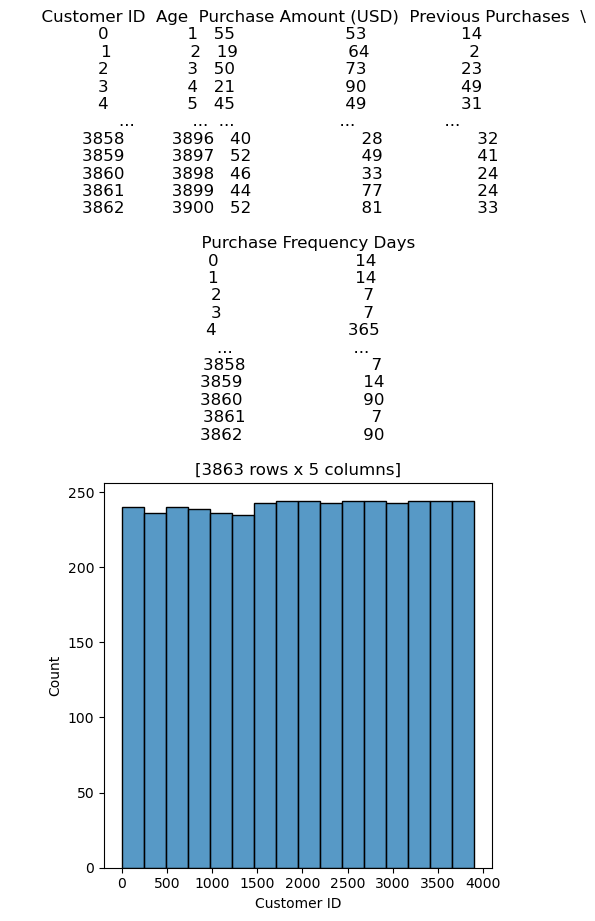

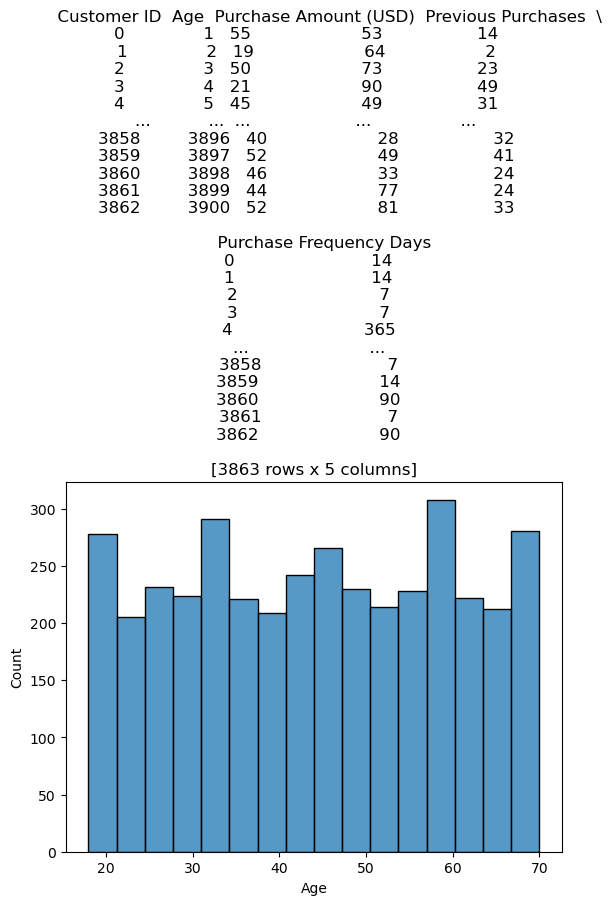

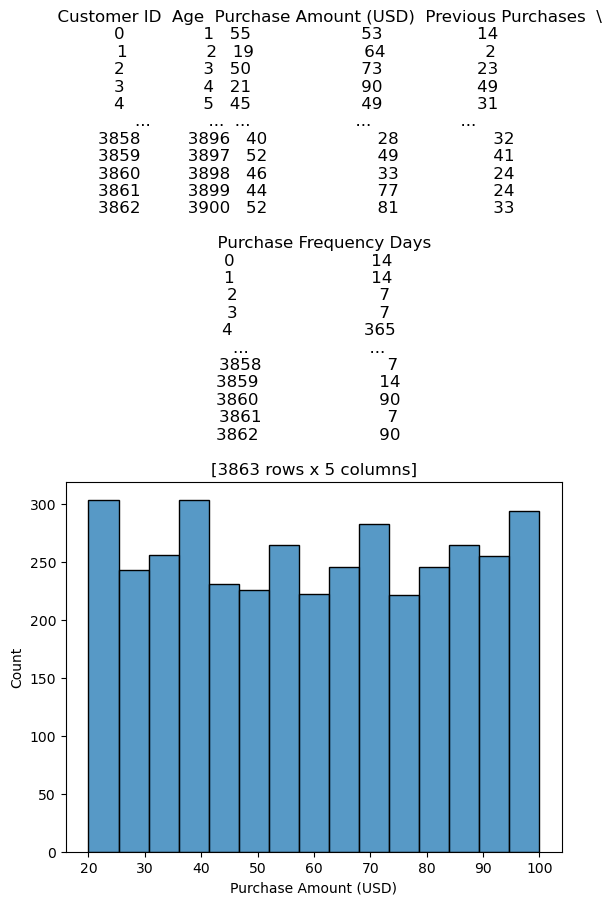

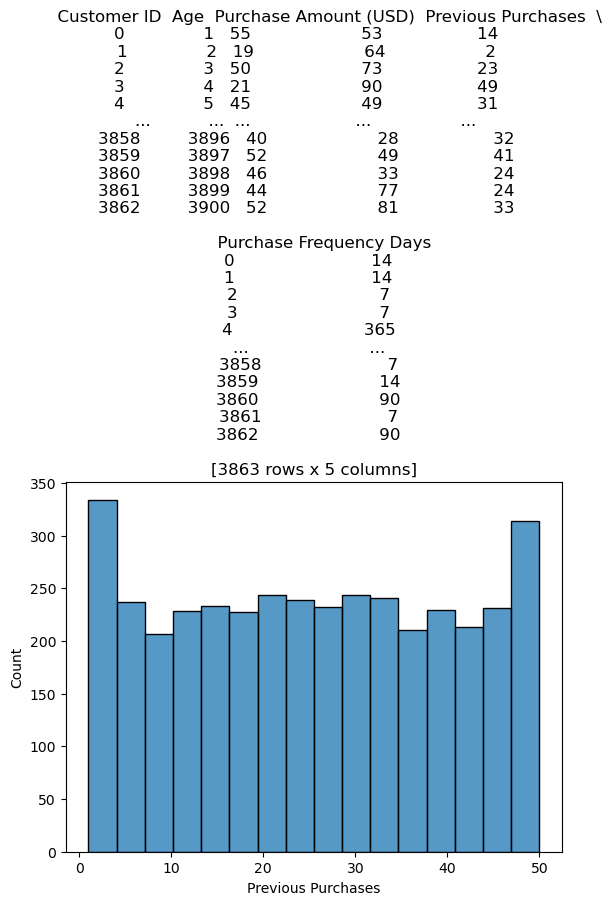

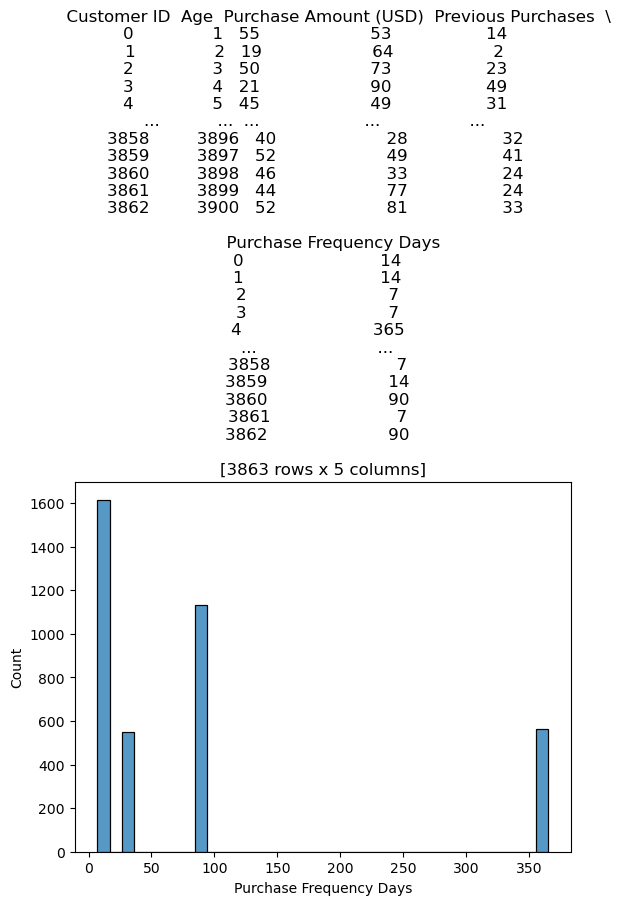

In [43]:
plt.figure(figsize=(5,5))
for i in col:
    sns.histplot(df[i])
    plt.title(col)
    plt.tight_layout()
    plt.show()

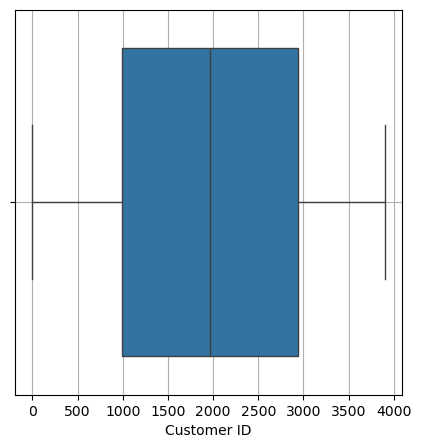

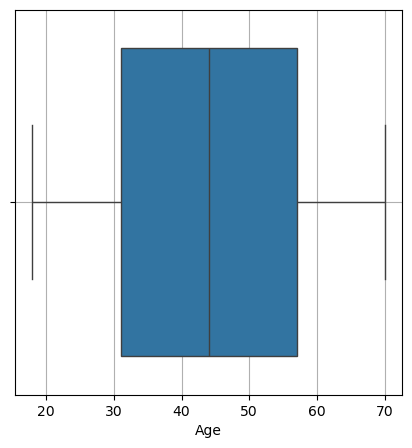

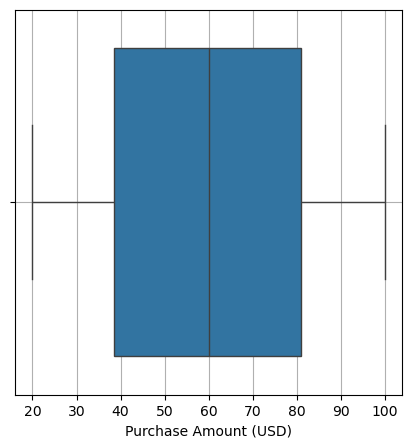

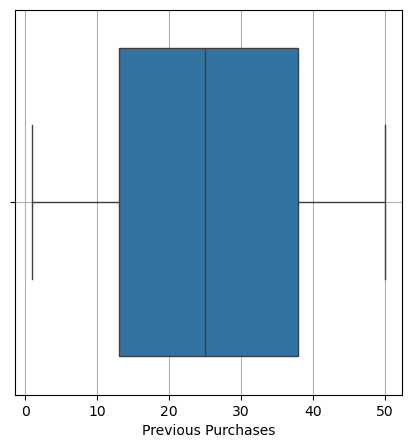

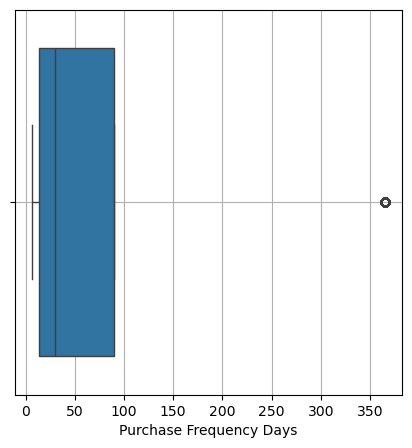

In [44]:
for i in col:
    plt.figure(figsize=(5,5))
    sns.boxplot(x=df[i])
    plt.grid()

In [45]:
df.corr(numeric_only=True).style.background_gradient()

,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases,Purchase Frequency Days
Customer ID,1.000000,-0.004551,0.013244,0.000247,-0.038644,0.006742
Age,-0.004551,1.000000,-0.012531,-0.024384,0.041974,0.019084
Purchase Amount (USD),0.013244,-0.012531,1.000000,0.029859,0.009306,0.008803
Review Rating,0.000247,-0.024384,0.029859,1.000000,0.003583,0.004257
Previous Purchases,-0.038644,0.041974,0.009306,0.003583,1.000000,-0.016976
Purchase Frequency Days,0.006742,0.019084,0.008803,0.004257,-0.016976,1.000000


In [67]:
df['Age Grouped']=pd.cut(df['Age'],labels=['Young','Adult','Senior'],bins=[17,25,40,70])
df['Age Grouped']


0       Senior
1        Young
2       Senior
3        Young
4       Senior
         ...  
3858     Adult
3859    Senior
3860    Senior
3861    Senior
3862    Senior
Name: Age Grouped, Length: 3863, dtype: category
Categories (3, object): ['Young' < 'Adult' < 'Senior']

In [68]:
grouped=df.groupby('Age Grouped')[['Purchase Amount (USD)','Review Rating','Purchase Frequency Days']].mean().round(2)
grouped.reset_index()


,Age Grouped,Purchase Amount (USD),Review Rating,Purchase Frequency Days
0,Young,60.57,3.82,95.09
1,Adult,59.72,3.75,84.50
2,Senior,59.47,3.73,89.58


*In this young group spends more 
*Adult group are more engaged they purchases frequntly
*Senior group spends less

In [69]:
df['Customer type']=df['Previous Purchases'].apply(lambda x:'Frequent' if x>10 else 'Occasional')

In [70]:
df

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Previous Purchases,Payment Method,Purchase Frequency Days,Age Grouped,Customer type
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,14,Venmo,14,Senior,Frequent
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,2,Cash,14,Young,Occasional
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,23,Credit Card,7,Senior,Frequent
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,49,PayPal,7,Young,Frequent
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,31,PayPal,365,Senior,Frequent
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3858,3896,40,Female,Hoodie,Clothing,28,Virginia,L,Turquoise,Summer,4.2,No,2-Day Shipping,No,32,Venmo,7,Adult,Frequent
3859,3897,52,Female,Backpack,Accessories,49,Iowa,L,White,Spring,4.5,No,Store Pickup,No,41,Bank Transfer,14,Senior,Frequent
3860,3898,46,Female,Belt,Accessories,33,New Jersey,L,Green,Spring,2.9,No,Standard,No,24,Venmo,90,Senior,Frequent
3861,3899,44,Female,Shoes,Footwear,77,Minnesota,S,Brown,Summer,3.8,No,Express,No,24,Venmo,7,Senior,Frequent


In [72]:
df.to_csv('Customer_behavior_analysis_cleaned.csv',index=False)